# 08 — Model 1: XGBoost Regression — Prediksi Views (Optimized)
**Target:** `views` (penayangan_tak_dilewati)  
**Peningkatan**: Mengimplementasikan seleksi fitur otomatis untuk menghilangkan multikolinearitas (korelasi > 0.85).  
**Algoritma:** XGBoost Regressor + 5-Fold CV + Early Stopping  
**Output:** `backend/models/model1_xgboost_regression.pkl`, `data/processed/model_output_regression.csv`

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print("Libraries loaded ✓")

Libraries loaded ✓


In [23]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
df = pd.read_csv('../../data/processed/features_merged.csv')
print(f"Shape asal: {df.shape}")

FEATURES = [
    'growth_1_to_2', 'growth_2_to_3', 'growth_3_to_4', 'avg_growth_rate',
    'growth_trend', 'peak_views', 'views_volatility',
    'view_velocity', 'video_age_days', 'day_of_week', 'month', 'is_weekend',
    'is_viral', 'video_duration_sec', 'watch_time_hours',
    'like_rate', 'dislike_rate', 'comment_rate', 'like_dislike_ratio',
    'retention_proxy', 'engagement_score', 'engagement_quality',
    'ctr_normalized', 'impression_to_view_rate', 'ctr_impression_score',
    'ctr_vs_channel_avg', 'ctr_category',
    'rolling_avg_views', 'rolling_mean_views_7d', 'ema_views_5',
    'views_trend_ratio', 'rolling_cv_views', 'decayed_historical_views',
    'is_declining', 'views_deviation',
    'revenue_per_view', 'is_monetized', 'ad_impression_rate', 'revenue_category',
]
TARGET = 'views'
FEATURES = [f for f in FEATURES if f in df.columns]

X_raw = df[FEATURES].copy()
y = np.log1p(df[TARGET])

Shape asal: (2355, 56)


In [24]:
# ── 2. ELIMINASI MULTIKOLINEARITAS (Korelasi > 0.85) ─────────────────────────
# Temukan fitur yang memiliki korelasi tinggi antar sesamanya
corr_matrix = X_raw.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = []
for col in upper.columns:
    high_corr_features = upper.index[upper[col] > 0.85].tolist()
    if high_corr_features:
        # Bandingkan korelasi col vs high_corr_features terhadap target y
        corr_col_target = abs(np.corrcoef(X_raw[col], y)[0, 1])
        for f in high_corr_features:
            corr_f_target = abs(np.corrcoef(X_raw[f], y)[0, 1])
            # Drop fitur yang memiliki korelasi lebih rendah terhadap target
            if corr_col_target < corr_f_target:
                if col not in to_drop: to_drop.append(col)
            else:
                if f not in to_drop: to_drop.append(f)

SELECTED_FEATURES = [f for f in FEATURES if f not in to_drop]
print(f"Fitur yang dibuang karena multikolinearitas ({len(to_drop)}): {to_drop}")
print(f"Fitur terpilih ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")

X = X_raw[SELECTED_FEATURES].copy()

Fitur yang dibuang karena multikolinearitas (9): ['growth_2_to_3', 'views_volatility', 'watch_time_hours', 'retention_proxy', 'engagement_quality', 'ctr_normalized', 'rolling_avg_views', 'ema_views_5', 'decayed_historical_views']
Fitur terpilih (30): ['growth_1_to_2', 'growth_3_to_4', 'avg_growth_rate', 'growth_trend', 'peak_views', 'view_velocity', 'video_age_days', 'day_of_week', 'month', 'is_weekend', 'is_viral', 'video_duration_sec', 'like_rate', 'dislike_rate', 'comment_rate', 'like_dislike_ratio', 'engagement_score', 'impression_to_view_rate', 'ctr_impression_score', 'ctr_vs_channel_avg', 'ctr_category', 'rolling_mean_views_7d', 'views_trend_ratio', 'rolling_cv_views', 'is_declining', 'views_deviation', 'revenue_per_view', 'is_monetized', 'ad_impression_rate', 'revenue_category']


In [25]:
# ── 3. TRAIN/TEST SPLIT (80/20 kronologis) ────────────────────────────────
split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1884, 30) | Test: (471, 30)


In [26]:
# ── 4. XGBOOST MODEL (Anti-Overfitting Config) ───────────────────────────────
xgb = XGBRegressor(
    n_estimators        = 500,
    learning_rate       = 0.05,
    max_depth           = 5,
    min_child_weight    = 5,
    subsample           = 0.80,
    colsample_bytree    = 0.80,
    reg_alpha           = 0.1,
    reg_lambda          = 1.5,
    gamma               = 0.1,
    random_state        = RANDOM_SEED,
    eval_metric         = 'rmse',
    early_stopping_rounds = 50,
    n_jobs              = -1,
    verbosity           = 0,
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print(f"Best iteration: {xgb.best_iteration}")

Best iteration: 496


In [27]:
# ── 5. EVALUASI TRAIN vs TEST ─────────────────────────────────────────────────
def metrics(y_true, y_pred, label=''):
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-9))) * 100
    print(f"[{label}] RMSE(log)={rmse:.4f} | MAE(log)={mae:.4f} | R²={r2:.4f} | MAPE={mape:.2f}%")
    return dict(label=label, rmse=rmse, mae=mae, r2=r2, mape=mape)

y_pred_train = xgb.predict(X_train)
y_pred_test  = xgb.predict(X_test)

m_train = metrics(y_train, y_pred_train, 'TRAIN')
m_test  = metrics(y_test,  y_pred_test,  'TEST ')

[TRAIN] RMSE(log)=0.1065 | MAE(log)=0.0831 | R²=0.9950 | MAPE=8.25%
[TEST ] RMSE(log)=0.1643 | MAE(log)=0.1226 | R²=0.9857 | MAPE=12.12%


In [28]:
# ── 6. 5-FOLD CROSS VALIDATION ───────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=False)
cv_r2, cv_rmse, cv_mape = [], [], []

xgb_cv = XGBRegressor(
    n_estimators        = xgb.best_iteration + 1,
    learning_rate       = 0.05,
    max_depth           = 5,
    min_child_weight    = 5,
    subsample           = 0.80,
    colsample_bytree    = 0.80,
    reg_alpha           = 0.1,
    reg_lambda          = 1.5,
    gamma               = 0.1,
    random_state        = RANDOM_SEED,
    n_jobs              = -1,
    verbosity           = 0,
)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
    ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]
    xgb_cv.fit(Xtr, ytr, verbose=False)
    yhat = xgb_cv.predict(Xval)
    r2_  = r2_score(yval, yhat)
    rmse_= np.sqrt(mean_squared_error(yval, yhat))
    mape_= np.mean(np.abs((np.expm1(yval)-np.expm1(yhat))/(np.expm1(yval)+1e-9)))*100
    cv_r2.append(r2_); cv_rmse.append(rmse_); cv_mape.append(mape_)

print(f"CV Mean R²:   {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"CV Mean MAPE: {np.mean(cv_mape):.2f}%")

CV Mean R²:   0.9833 ± 0.0041
CV Mean MAPE: 13.40%


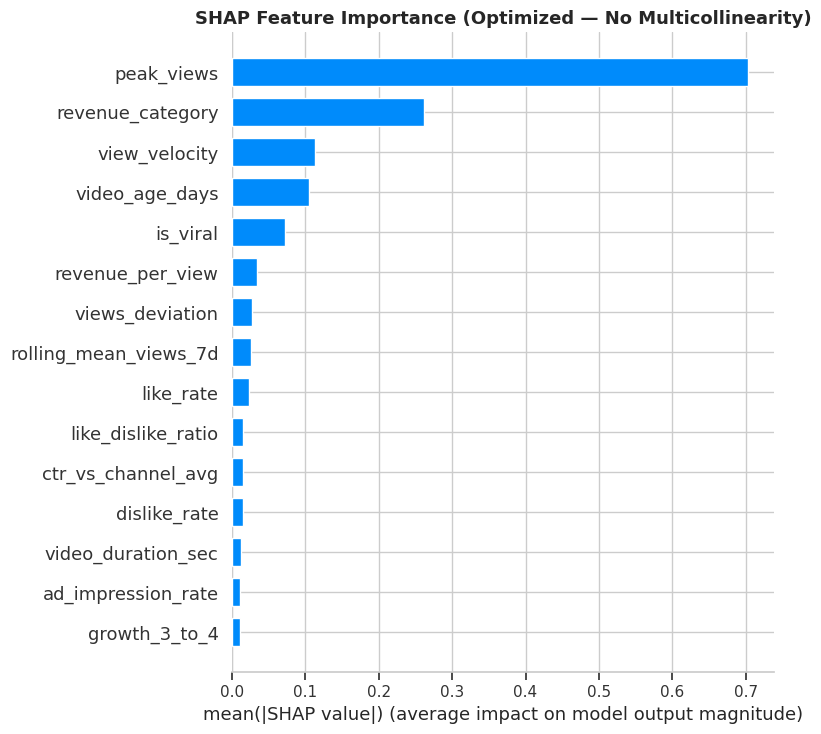

In [29]:
# ── 7. SHAP FEATURE IMPORTANCE ────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance (Optimized — No Multicollinearity)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# ── 8. SIMPAN MODEL ──────────────────────────────────────────────────────────
os.makedirs('../../backend/models', exist_ok=True)
joblib.dump(xgb, '../../backend/models/model1_xgboost_regression.pkl')
joblib.dump(SELECTED_FEATURES, '../../backend/models/model1_selected_features.pkl')

output_df = df.iloc[split_idx:][['video_id','views']].copy()
output_df['views_predicted'] = np.clip(np.expm1(y_pred_test), 0, None).astype(int)
output_df.to_csv('../../data/processed/model_output_regression.csv', index=False)
print("Saved artifacts ✓")

Saved artifacts ✓
